# Reto de la semana 4: Optimización de Regresión Logística

En este reto, usando la función de pérdida construida la semana pasada, se resuelve un problema de optimización para encontrar el clasificador que minimiza esta función.

El conjunto de datos utilizado nuevamente es `BreastCancer`, una base de datos real con **469 observaciones** y **2 características** (`radius_mean` y `smoothness_mean`), ambas estandarizadas. La variable objetivo `pronostic` indica si la muestra es maligna ($t = 1$) o benigna ($t = 0$).

### Formulación del clasificador

Dado un dato de entrada $x = [x_1, x_2] \in \mathbb{R}^2$, se define el vector aumentado $z = [x, 1]^T$ y el vector de parámetros $w = [w_1, w_2, w_3]^T$. La regla de clasificación es:

$$
\begin{cases}
w^T z = w_1 x_1 + w_2 x_2 + w_3 > 0 & \Rightarrow x \text{ es clase } 1 \\
w^T z = w_1 x_1 + w_2 x_2 + w_3 < 0 & \Rightarrow x \text{ es clase } 0
\end{cases}
$$

La calidad del clasificador se mide a través de la **función de pérdida.**

## Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Carga y organización de los datos

Se separan las variables del conjunto de datos en:

- $X \in \mathbb{R}^{m \times 2}$: matriz de características, donde cada fila corresponde a un vector $(x_1, x_2)$. En este caso $x_1 = $ `radius_mean` y $x_2 = $ `smoothness_mean`, ambas ya **estandarizadas.**
- $t \in \{0, 1\}^m$: vector de etiquetas (`pronostic`), donde $1$ indica muestra maligna y $0$ benigna.

In [14]:
# Cargar el dataset
df = pd.read_csv('BreastCancer.csv')
df.head()

,radius_mean,smoothness_mean,pronostic
0,0.950308,1.523620,1
1,1.646970,-0.893636,1
2,1.409349,0.891658,1
3,-0.823748,3.254336,1
4,1.571363,0.223788,1


In [15]:
# Separar características y etiquetas
X = df.iloc[:, :-1].values   # x1 = radius_mean, x2 = smoothness_mean
t = df.iloc[:, -1].values    # etiquetas: 0 = benigno, 1 = maligno

# Ver dimensiones
print('Shape de X:', X.shape)
print('Shape de t:', t.shape)

Shape de X: (469, 2)
Shape de t: (469,)


## Gráfico de dispersión

Se construye un gráfico de dispersión para representar cada observación en el plano $(x_1, x_2)$.

Para facilitar la interpretación:
- Las observaciones con $t = 0$ se representan en **color azul** (benigno).
- Las observaciones con $t = 1$ se representan en **color rojo** (maligno).

Esto permite visualizar la distribución de los datos en el espacio de características.

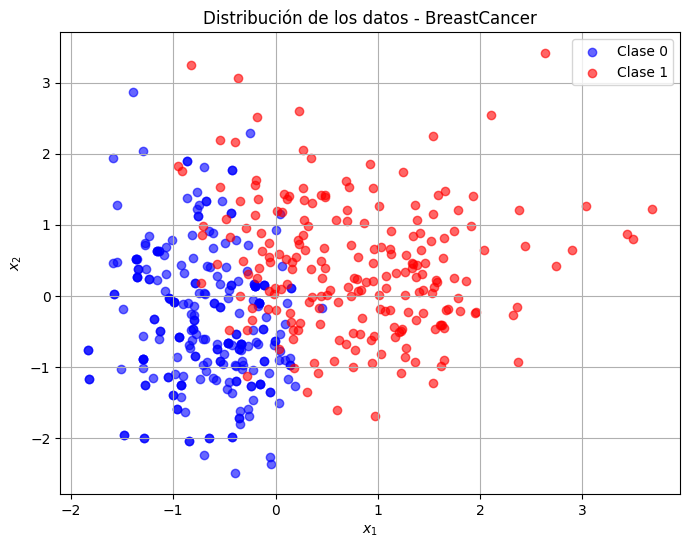

In [16]:
plt.figure(figsize=(8,6))

# Clase 0
plt.scatter(X[t == 0, 0], X[t == 0, 1],
            color='blue', label='Clase 0', alpha=0.6)
# X[t == 0, 0] -> valores de x1 de clase 0
# X[t == 0, 1] -> valores de x2 de clase 0
# Se grafican en azul

# Clase 1
plt.scatter(X[t == 1, 0], X[t == 1, 1],
            color='red', label='Clase 1', alpha=0.6)
# Se grafican en rojo

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Distribución de los datos - BreastCancer')
plt.legend()    # Muestra la leyenda (Clase 0, Clase 1)
plt.grid()
plt.show()

## Funciones del reto anterior

### Función sigmoide

La función sigmoide transforma cualquier valor real en un valor entre $0$ y $1$:

$$
\sigma(s) = \frac{1}{1 + e^{-s}}
$$

### Función de pérdida

Dada la matriz aumentada $z^{(i)} = [x^{(i)}, 1]^T$, las predicciones son $y_i = \sigma(w^T z^{(i)})$ y la pérdida se calcula como:

$$
f(w) = -\frac{1}{m} \sum_{i=1}^{m} \left[ t_i \log y_i + (1 - t_i) \log(1 - y_i) \right]
$$

>**Nota:** Se aplica `np.clip` para evitar $\log(0)$, reemplazando valores extremos por $\varepsilon = 10^{-10}$.

In [ ]:
def sigmoid(z):
    """
    Función sigmoide:
    transforma cualquier valor real en un valor entre 0 y 1
    """
    return 1 / (1 + np.exp(-z))


def loss_function(w, X, t):
    """
    Calcula la función de pérdida de regresión logística

    w: vector de parámetros (w1, w2, w3)
    X: matriz de datos (x1, x2)
    t: etiquetas (0 o 1)
    """
    m = len(t)

    # Construir z = (x1, x2, 1)
    Z = np.hstack([X, np.ones((m,1))])

    # Predicciones
    y = sigmoid(Z @ w)

    # Evitar log(0)
    epsilon = 1e-10
    y = np.clip(y, epsilon, 1 - epsilon)

    # Función de pérdida
    f = -(1/m) * np.sum(t * np.log(y) + (1 - t) * np.log(1 - y))

    return f


# Ejemplo de vector w
w = np.array([1, -1, 0])

# Calcular pérdida
valor_loss = loss_function(w, X, t)
print('f(w) =', valor_loss)

f(w) = 0.6870220839104795



## (a) Resolución del problema de optimización

Se plantea el siguiente problema de optimización sin restricciones:

$$
\min_{w} \; f(w) \qquad \text{sujeto a } w \in \mathbb{R}^3
$$

Para resolverlo se utiliza el solver `minimize` de `scipy.optimize` con el método **BFGS**, un algoritmo cuasi-Newton eficiente para problemas diferenciables.

Se provee el **gradiente analítico** para acelerar la convergencia. Derivando $f(w)$ con respecto a $w$ se obtiene:

$$
\nabla f(w) = \frac{1}{m} Z^T (y - t)
$$

donde $y = \sigma(Zw)$ es el vector de predicciones y $Z \in \mathbb{R}^{m \times 3}$ es la matriz de datos con la columna de unos añadida.

In [19]:
def gradiente(w, X, t):
    """
    Gradiente analítico de la función de pérdida:
        ∇f(w) = (1/m) * Z^T (y - t)

    w: vector de parámetros (w1, w2, w3)
    X: matriz de datos (x1, x2)
    t: etiquetas (0 o 1)
    """
    m = len(t)

    # Construir Z con columna de unos
    Z = np.hstack([X, np.ones((m, 1))])

    # Predicciones
    y = sigmoid(Z @ w)

    # Gradiente: (1/m) * Z^T (y - t)
    return (1 / m) * Z.T @ (y - t)


# Punto inicial: w = [0, 0, 0]
w0 = np.zeros(3)

# Resolver el problema de optimización con BFGS
resultado = minimize(
    fun=loss_function,       # función objetivo
    x0=w0,                   # punto inicial
    args=(X, t),             # argumentos extra para loss_function y gradiente
    jac=gradiente,           # gradiente analítico (más preciso y rápido)
    method='BFGS',
    options={'maxiter': 1000, 'gtol': 1e-8}
)

# w óptimo encontrado
w_opt = resultado.x

print(f'Convergió     : {resultado.success}')
print(f'Iteraciones   : {resultado.nit}')
print(f'\nw* óptimo encontrado:')
print(f'  w1 = {w_opt[0]:.6f}')
print(f'  w2 = {w_opt[1]:.6f}')
print(f'  w3 = {w_opt[2]:.6f} (posible sesgo)')
print(f'\nf(w*) = {loss_function(w_opt, X, t):.8f}')

Convergió     : True
Iteraciones   : 23

w* óptimo encontrado:
  w1 = 5.359008
  w2 = 1.641291
  w3 = 0.244419 (posible sesgo)

f(w*) = 0.20464127


### Análisis — Inciso (a)

El solver BFGS convergió exitosamente en **23 iteraciones**, encontrando el vector óptimo $w^* = [5.359,\; 1.641,\; 0.244]^T$ con un valor de pérdida de $f(w^*) = 0.2046$. Comparado con el valor inicial evaluado en $w = [1, -1, 0]$, que arrojaba $f(w) = 0.6870$, la optimización logró reducir la pérdida en aproximadamente un **70%**, lo que indica una mejora sustancial en la capacidad de clasificación del modelo.

Los valores positivos y relativamente grandes de $w_1$ y $w_2$ indican que ambas características (`radius_mean` y `smoothness_mean`) contribuyen positivamente a la predicción de malignidad. El sesgo $w_3 = 0.244$ desplaza levemente la frontera de decisión hacia la región de clase 0, reflejando que en los datos hay un leve desbalance hacia muestras benignas.

## (b) Frontera de decisión sobre el scatter plot

La **frontera de decisión** es el conjunto de puntos donde el clasificador no diferencia entre clase $0$ y clase $1$:

$$
w^T z = w_1 x_1 + w_2 x_2 + w_3 = 0
$$

Despejando $x_2$, se obtiene la ecuación de la recta separadora:

$$
x_2 = -\frac{w_1 x_1 + w_3}{w_2}
$$

Para que la visualización sea clara, la recta se limita al rango de valores de los datos mediante `plt.xlim` y `plt.ylim`, evitando que la frontera se extienda fuera de la región donde se encuentran las observaciones.

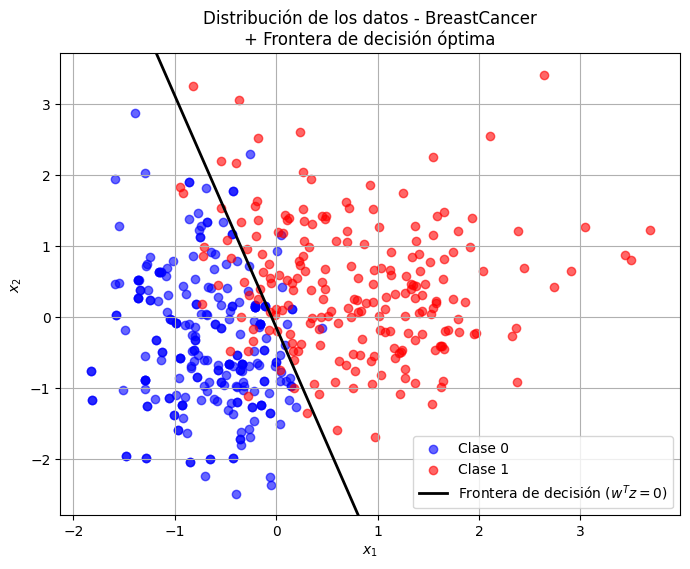

In [20]:
# Márgenes para el área visible del gráfico
margen = 0.3
x1_min, x1_max = X[:, 0].min() - margen, X[:, 0].max() + margen
x2_min, x2_max = X[:, 1].min() - margen, X[:, 1].max() + margen

plt.figure(figsize=(8, 6))

# Scatter de los datos
plt.scatter(X[t == 0, 0], X[t == 0, 1],
            color='blue', label='Clase 0', alpha=0.6)
plt.scatter(X[t == 1, 0], X[t == 1, 1],
            color='red', label='Clase 1', alpha=0.6)

# Frontera de decisión: x2 = -(w1*x1 + w3) / w2
# Se genera sobre todo el rango de x1 y matplotlib recorta al área visible
x1_vals = np.linspace(x1_min, x1_max, 300)
x2_vals = -(w_opt[0] * x1_vals + w_opt[2]) / w_opt[1]

plt.plot(x1_vals, x2_vals, 'k-', linewidth=2,
         label=r'Frontera de decisión ($w^Tz = 0$)')

# Limitar los ejes al rango real de los datos
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Distribución de los datos - BreastCancer\n+ Frontera de decisión óptima')
plt.legend()
plt.grid()
plt.show()

### Análisis — Inciso (b)

La frontera de decisión obtenida separa de forma razonablemente efectiva las dos clases en el espacio de características. Se puede observar que las muestras malignas (rojo) tienden a concentrarse en la región donde $x_1$ toma valores altos, es decir, donde el radio medio del núcleo celular es mayor, lo cual es consistente con el conocimiento médico: tumores malignos presentan núcleos de mayor tamaño. La recta separa bien la mayoría de los puntos, aunque existe una zona de solapamiento entre las clases, especialmente para valores intermedios de $x_1$, lo que refleja la dificultad inherente del problema con solo dos características linealmente separables de forma aproximada.

## (c) Valor objetivo, gradiente y Hessiana en $w^*$

### Valor de la función objetivo

Se evalúa $f(w^*)$ directamente con la función de pérdida.

### Gradiente en $w^*$

En un punto óptimo $w^*$, la condición de primer orden exige:

$$
\nabla f(w^*) = \frac{1}{m} Z^T(y - t) \approx \mathbf{0}
$$

Un gradiente cercano a cero confirma que el solver convergió correctamente.

### Hessiana en $w^*$

La Hessiana se obtiene derivando el gradiente:

$$
H(w) = \frac{1}{m} Z^T D Z
$$

donde $D = \text{diag}\left(y_i(1 - y_i)\right)$ es una matriz diagonal con los términos de curvatura de la sigmoide.

> Si todos los **valores propios** de $H(w^*)$ son positivos, entonces $H$ es **definida positiva**, lo cual garantiza que $f$ es convexa y que $w^*$ es un **mínimo global**.

In [23]:
def hessiana(w, X, t):
    """
    Hessiana analítica de la función de pérdida:
        H(w) = (1/m) * Z^T D Z
    donde D = diag(y_i * (1 - y_i))

    w: vector de parámetros (w1, w2, w3)
    X: matriz de datos (x1, x2)
    t: etiquetas (0 o 1)
    """
    m = len(t)

    # Construir Z con columna de unos
    Z = np.hstack([X, np.ones((m, 1))])

    # Predicciones
    y = sigmoid(Z @ w)

    # Matriz diagonal D = diag(y_i * (1 - y_i))
    D = np.diag(y * (1 - y))

    # Hessiana: (1/m) * Z^T D Z
    return (1 / m) * Z.T @ D @ Z


# --- Valor de la función objetivo en w* ---
f_opt = loss_function(w_opt, X, t)
print('► Valor de la función objetivo:')
print(f'   f(w*) = {f_opt:.8f}')

# --- Gradiente en w* ---
grad_opt = gradiente(w_opt, X, t)
print('\n► Gradiente en w*  (debe ser ≈ 0 si hubo convergencia):')
print(f'   ∇f(w*) = [{grad_opt[0]:.2e},  {grad_opt[1]:.2e},  {grad_opt[2]:.2e}]')
print(f'   ‖∇f(w*)‖ = {np.linalg.norm(grad_opt):.2e}')

# --- Hessiana en w* ---
hess_opt = hessiana(w_opt, X, t)
print('\n► Hessiana en w*  —  H(w*) ∈ ℝ3x3:')
print(np.array2string(hess_opt, precision=6, floatmode='fixed'))

# Verificar convexidad mediante valores propios
eigenvalues = np.linalg.eigvalsh(hess_opt)
print(f'\n► Valores propios de H(w*): {np.round(eigenvalues, 6)}')
print(f'   H es definida positiva: {np.all(eigenvalues > 0)}  →  mínimo global ✓')

► Valor de la función objetivo:
   f(w*) = 0.20464127

► Gradiente en w*  (debe ser ≈ 0 si hubo convergencia):
   ∇f(w*) = [-1.03e-11,  2.73e-11,  3.03e-10]
   ‖∇f(w*)‖ = 3.04e-10

► Hessiana en w*  —  H(w*) ∈ ℝ3x3:
[[ 0.010059 -0.013567 -0.010393]
 [-0.013567  0.054774  0.009948]
 [-0.010393  0.009948  0.063297]]

► Valores propios de H(w*): [0.00529  0.048827 0.074013]
   H es definida positiva: True  →  mínimo global ✓


### Análisis — Inciso (c)

El valor de la función objetivo en el óptimo es $f(w^*) = 0.2046$, lo que representa la pérdida mínima alcanzable por un clasificador lineal con los parámetros $w \in \mathbb{R}^3$ sobre este conjunto de datos.

La norma del gradiente en $w^*$ es $\|\nabla f(w^*)\| \approx 3.04 \times 10^{-10}$, un valor numéricamente indistinguible de cero. Esto confirma que se satisface la **condición de optimalidad de primer orden** $\nabla f(w^*) = \mathbf{0}$, es decir, que el punto encontrado por el solver es efectivamente un punto crítico de la función de pérdida.

La Hessiana $H(w^*)$ presenta tres valores propios estrictamente positivos: $0.00529$, $0.04883$ y $0.07401$. Al ser todos mayores que cero, la Hessiana es **definida positiva**, lo cual garantiza que $f$ es una función estrictamente convexa en un entorno de $w^*$. En consecuencia, el punto crítico encontrado es un **mínimo global** de la función de pérdida, y no existe ningún otro $w$ que pueda producir un valor de $f$ menor. Esto es una propiedad clave de la regresión logística: su función de pérdida es convexa, lo que hace que el problema de optimización sea bien comportado y que el solver siempre encuentre la solución óptima independientemente del punto de partida.

In [25]:
!jupyter nbconvert --to html "challenge_week4.ipynb" #Crear .html

[NbConvertApp] Converting notebook challenge_week4.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 497290 bytes to challenge_week4.html
